# Phase 2 - Expolatory Data Analysis and Visualisation
#### Exracting data from MongoDB and performing initial baseline visualisation

EDA plan
1. connect & Load Data
2. Data Quality Check
3. Univariate Analysis (each column individually)
4. Bivariate Analysis (relationships between columns)
5. Time Analysis (visits over the semester)
6. Severity Analysis
7. Key Insights Summary

### 1 - Connecting & Loading Data

In [1]:
import pandas as pd
import numpy as np
from pymongo import MongoClient
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# --- Plot style ---
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor': '#1a1d2e',
    'axes.edgecolor': '#2d3148',
    'axes.labelcolor': '#9ca3af',
    'xtick.color': '#6b7280',
    'ytick.color': '#6b7280',
    'text.color': '#e5e7eb',
    'grid.color': '#2d3148',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'font.family': 'serif',
})
TEAL   = '#00c9a7'
BLUE   = '#0072ff'
AMBER  = '#f59e0b'
RED    = '#ff6b6b'
PURPLE = '#a78bfa'
PALETTE = [TEAL, BLUE, AMBER, RED, PURPLE, '#fb923c', '#6ee7b7']

print('Libraries loaded ✓')

Libraries loaded ✓


In [2]:
# 1. Connectting to MongoDB instance
client = MongoClient("mongodb://localhost:27017/")
db = client["UniMediTrend"]
collection = db["clinic_logs"]

# 2. Fetch the data (excluding the MongoDB specific '_id' object for cleaner data)
cursor = collection.find({}, {"_id": 0})

# 3. Load into a Pandas DataFrame
df = pd.DataFrame(list(cursor))

In [3]:
# 4. Sanity Check
df.head()

,visit_date,level,gender,department,hostel,diagnosis,severity
0,2024-01-15,200,Male,Electrical & Electronic Engineering,Gold Refinery Hall,Physical Injury,1
1,2024-01-15,400,Female,Electrical & Electronic Engineering,The Point Hostel,Stress/Fatigue,3
2,2024-01-15,400,Female,Computer Science & Engineering,Castle Gate,Food Poisoning,2
3,2024-01-15,200,Male,Mining Engineering,Kabi's Hostel,Physical Injury,3
4,2024-01-15,300,Male,Mining Engineering,Gold Refinery Hall,Stress/Fatigue,1


## 2 - Data Quality Check

In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 5799 entries, 0 to 5798
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   visit_date  5799 non-null   datetime64[us]
 1   level       5799 non-null   int64         
 2   gender      5799 non-null   str           
 3   department  5799 non-null   str           
 4   hostel      5799 non-null   str           
 5   diagnosis   5799 non-null   str           
 6   severity    5799 non-null   int64         
dtypes: datetime64[us](1), int64(2), str(4)
memory usage: 606.0 KB
None


In [5]:
# --- Missing values ---
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print('No missing values ✓')
else:
    print('=== MISSING VALUES ===')
    print(missing_df)

    # Visual
    fig, ax = plt.subplots(figsize=(8, 4))
    missing_df['Missing %'].plot(kind='barh', ax=ax, color=RED)
    ax.set_title('Missing Values by Column (%)', color='#e5e7eb', pad=12)
    ax.set_xlabel('% Missing')
    plt.tight_layout()
    plt.show()

No missing values ✓


In [6]:
# --- Duplicates ---
dupes = df.duplicated().sum()
print(f'Duplicate rows: {dupes}')
if dupes > 0:
    df = df.drop_duplicates()
    print(f'Duplicates removed. New shape: {df.shape}')

# --- Unique values per categorical column ---
cat_cols = ['hostel', 'diagnosis', 'level', 'gender', 'department', 'severity']
for col in cat_cols:
    if col in df.columns:
        print(f'\n{col.upper()} — {df[col].nunique()} unique values:')
        print(df[col].value_counts().to_string())

Duplicate rows: 1
Duplicates removed. New shape: (5798, 7)

HOSTEL — 10 unique values:
hostel
Castle Gate              630
Gold Refinery Hall       613
Osborn                   602
Hilda                    594
Off Campus               587
Chamber of Mines Hall    582
New Excellence           559
K.T. Hall                549
Kabi's Hostel            542
The Point Hostel         540

DIAGNOSIS — 6 unique values:
diagnosis
Stress/Fatigue     1616
Malaria            1195
Common Cold         879
Typhoid             774
Physical Injury     691
Food Poisoning      643

LEVEL — 4 unique values:
level
100    1543
400    1441
300    1427
200    1387

GENDER — 2 unique values:
gender
Male      2921
Female    2877

DEPARTMENT — 8 unique values:
department
Computer Science & Engineering         768
Mining Engineering                     759
Petroleum Engineering                  730
Geomatic Engineering                   727
Electrical & Electronic Engineering    726
Mathematics                    

In [7]:
# --- Parse & engineer date features ---
df['visit_date'] = pd.to_datetime(df['visit_date'])

df['week_number']  = df['visit_date'].dt.isocalendar().week.astype(int)
df['month']        = df['visit_date'].dt.month
df['day_of_week']  = df['visit_date'].dt.day_name()
df['day_num']      = df['visit_date'].dt.dayofweek   # 0=Mon

print('Date features created: week_number, month, day_of_week')
df[['visit_date', 'week_number', 'month', 'day_of_week']].head()

Date features created: week_number, month, day_of_week


,visit_date,week_number,month,day_of_week
0,2024-01-15,3,1,Monday
1,2024-01-15,3,1,Monday
2,2024-01-15,3,1,Monday
3,2024-01-15,3,1,Monday
4,2024-01-15,3,1,Monday


## 3. Univariate Analysis

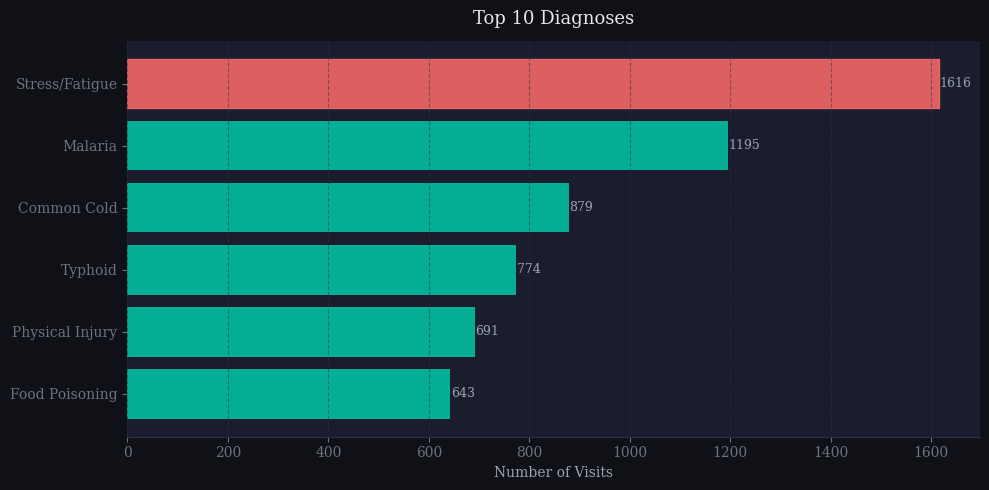


Top diagnosis: Stress/Fatigue (1616 visits, 27.9% of total)


In [8]:
# === 3a. Diagnosis Distribution ===
top_n = 10
diag_counts = df['diagnosis'].value_counts().head(top_n)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(diag_counts.index[::-1], diag_counts.values[::-1],
               color=TEAL, alpha=0.85, edgecolor='none')

# Color top bar differently
bars[-1].set_color(RED)

for bar, val in zip(bars, diag_counts.values[::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val}', va='center', fontsize=9, color='#9ca3af')

ax.set_title(f'Top {top_n} Diagnoses', fontsize=13, pad=12)
ax.set_xlabel('Number of Visits')
ax.grid(axis='x')
ax.spines[['top','right','left']].set_visible(False)
plt.tight_layout()
plt.show()

print(f"\nTop diagnosis: {diag_counts.index[0]} ({diag_counts.iloc[0]} visits, "
      f"{diag_counts.iloc[0]/len(df)*100:.1f}% of total)")

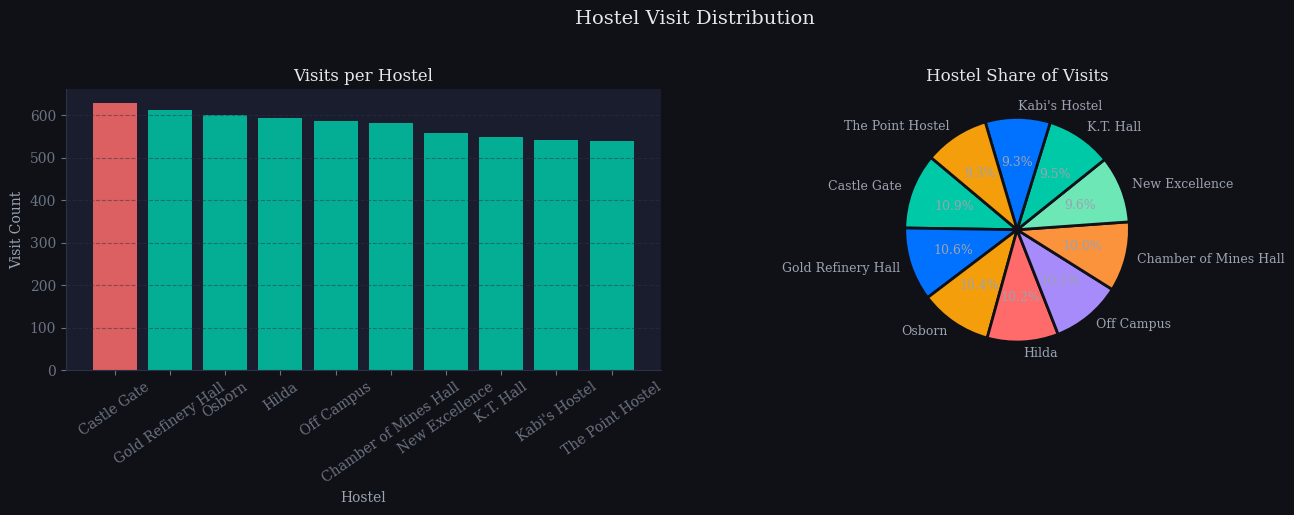

In [9]:
# === 3b. Hostel Distribution ===
hostel_counts = df['hostel'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = [RED if v == hostel_counts.max() else TEAL for v in hostel_counts.values]
axes[0].bar(hostel_counts.index, hostel_counts.values, color=colors, alpha=0.85, edgecolor='none')
axes[0].set_title('Visits per Hostel', fontsize=12)
axes[0].set_xlabel('Hostel')
axes[0].set_ylabel('Visit Count')
axes[0].tick_params(axis='x', rotation=35)
axes[0].grid(axis='y')
axes[0].spines[['top','right']].set_visible(False)

# Pie chart
axes[1].pie(hostel_counts.values, labels=hostel_counts.index,
            colors=PALETTE[:len(hostel_counts)],
            autopct='%1.1f%%', startangle=140,
            textprops={'color': '#9ca3af', 'fontsize': 9},
            wedgeprops={'edgecolor': '#0f1117', 'linewidth': 2})
axes[1].set_title('Hostel Share of Visits', fontsize=12)

plt.suptitle('Hostel Visit Distribution', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

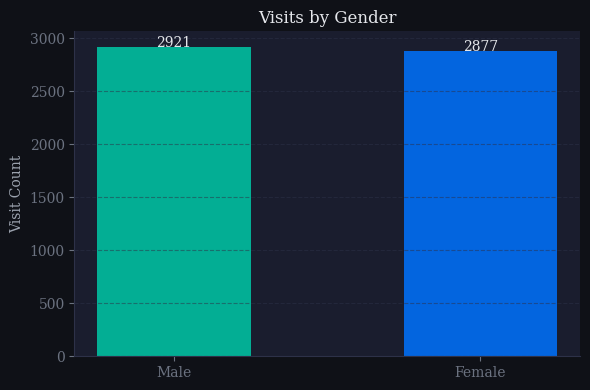

In [10]:
# === 3c. Gender Distribution ===
gender_counts = df['gender'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(gender_counts.index, gender_counts.values,
       color=[TEAL, BLUE], alpha=0.85, edgecolor='none', width=0.5)
for i, (label, val) in enumerate(gender_counts.items()):
    ax.text(i, val + 2, str(val), ha='center', fontsize=10, color='#e5e7eb')
ax.set_title('Visits by Gender', fontsize=12)
ax.set_ylabel('Visit Count')
ax.grid(axis='y')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

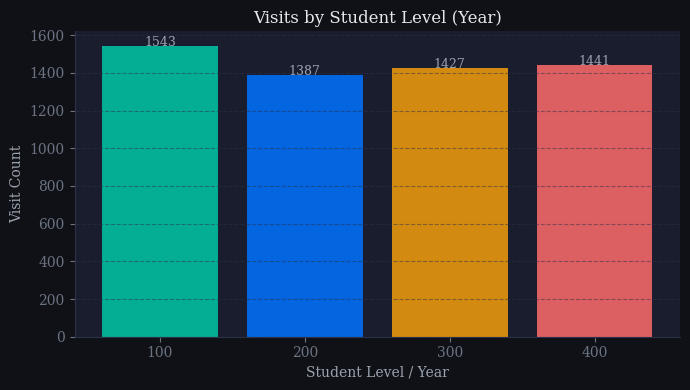

In [11]:
# === 3d. Student Level Distribution ===
level_counts = df['level'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(level_counts.index.astype(str), level_counts.values,
              color=PALETTE[:len(level_counts)], alpha=0.85, edgecolor='none')
for bar, val in zip(bars, level_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', fontsize=9, color='#9ca3af')
ax.set_title('Visits by Student Level (Year)', fontsize=12)
ax.set_xlabel('Student Level / Year')
ax.set_ylabel('Visit Count')
ax.grid(axis='y')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

## 4. Bivariate Analysis

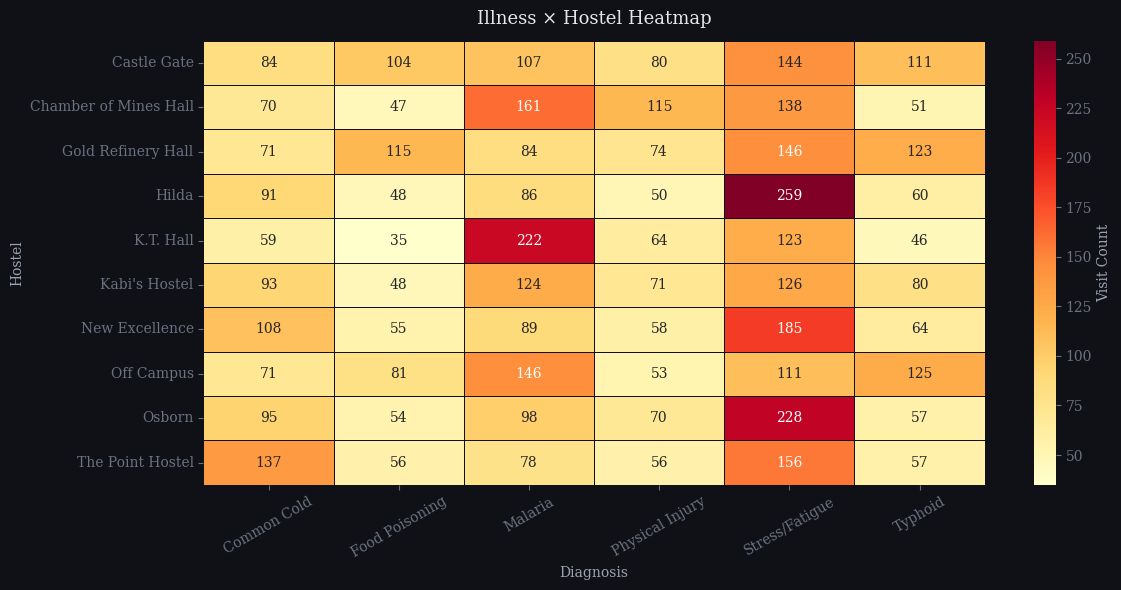

In [12]:
# === 4a. Diagnosis × Hostel Heatmap ===
top_diagnoses = df['diagnosis'].value_counts().head(6).index
df_top = df[df['diagnosis'].isin(top_diagnoses)]

pivot = pd.crosstab(df_top['hostel'], df_top['diagnosis'])

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, linecolor='#0f1117',
            ax=ax, cbar_kws={'label': 'Visit Count'})
ax.set_title('Illness × Hostel Heatmap', fontsize=13, pad=12)
ax.set_xlabel('Diagnosis')
ax.set_ylabel('Hostel')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

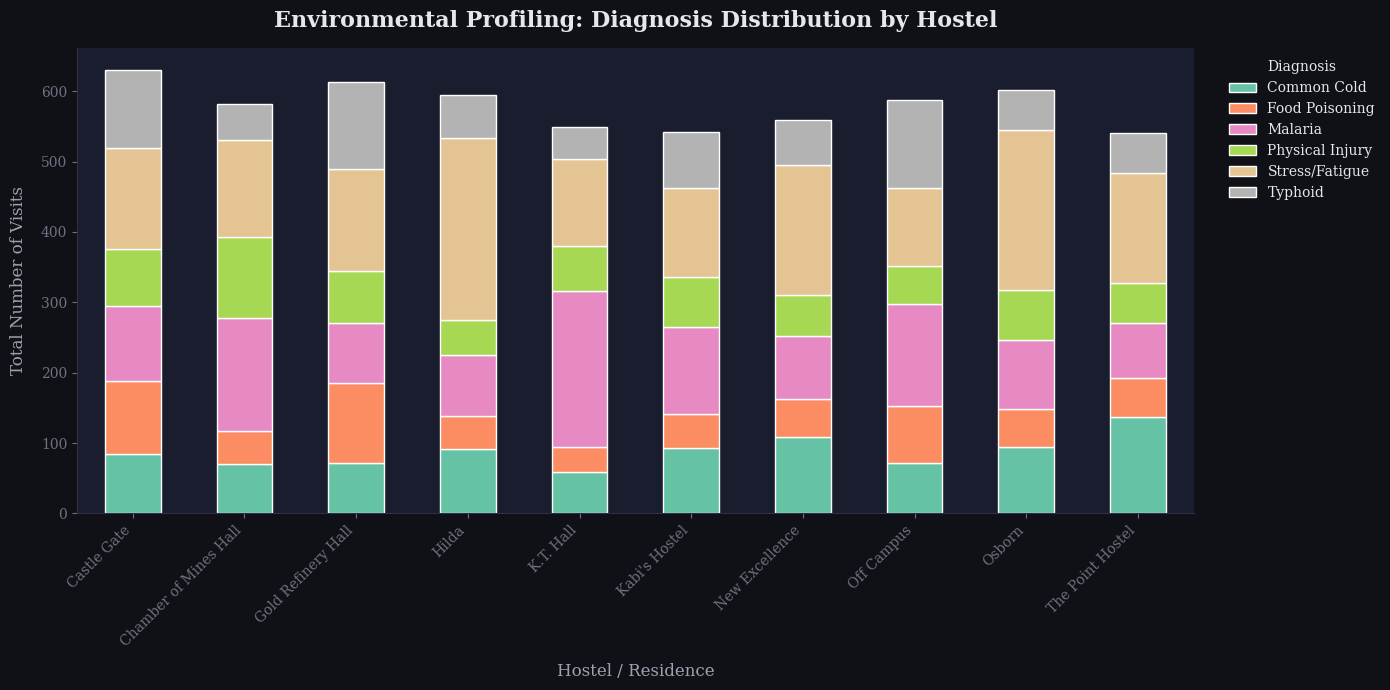

In [13]:
# === 4b. Hostel vs. Diagnosis (Hunting for the Malaria/Typhoid Spikes)===

# pd.crosstab creates a matrix of Hostels (rows) vs Diagnoses (columns)
hostel_diagnosis = pd.crosstab(df['hostel'], df['diagnosis'])

# Plotting a stacked bar chart
fig, ax1 = plt.subplots(figsize=(14, 7))
hostel_diagnosis.plot(kind='bar', stacked=True, ax=ax1, colormap='Set2', edgecolor='white', linewidth=1)

ax1.set_title("Environmental Profiling: Diagnosis Distribution by Hostel", fontsize=16, fontweight='bold', pad=15)
ax1.set_xlabel("Hostel / Residence", fontsize=12, labelpad=10)
ax1.set_ylabel("Total Number of Visits", fontsize=12, labelpad=10)

# Clean up axes and legend
plt.xticks(rotation=45, ha='right')
ax1.legend(title="Diagnosis", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


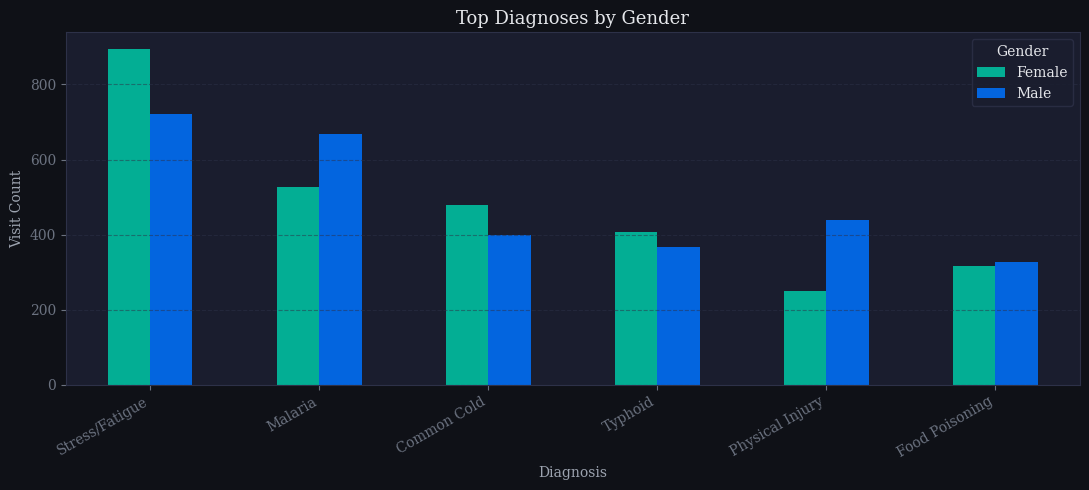

In [14]:
# === 4c. Gender × Diagnosis ===
gender_diag = pd.crosstab(df['diagnosis'], df['gender'])
gender_diag = gender_diag.loc[top_diagnoses]

gender_diag.plot(kind='bar', figsize=(11, 5),
                 color=[TEAL, BLUE], alpha=0.85, edgecolor='none')
plt.title('Top Diagnoses by Gender', fontsize=13)
plt.xlabel('Diagnosis')
plt.ylabel('Visit Count')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Gender', facecolor='#1a1d2e', edgecolor='#2d3148')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

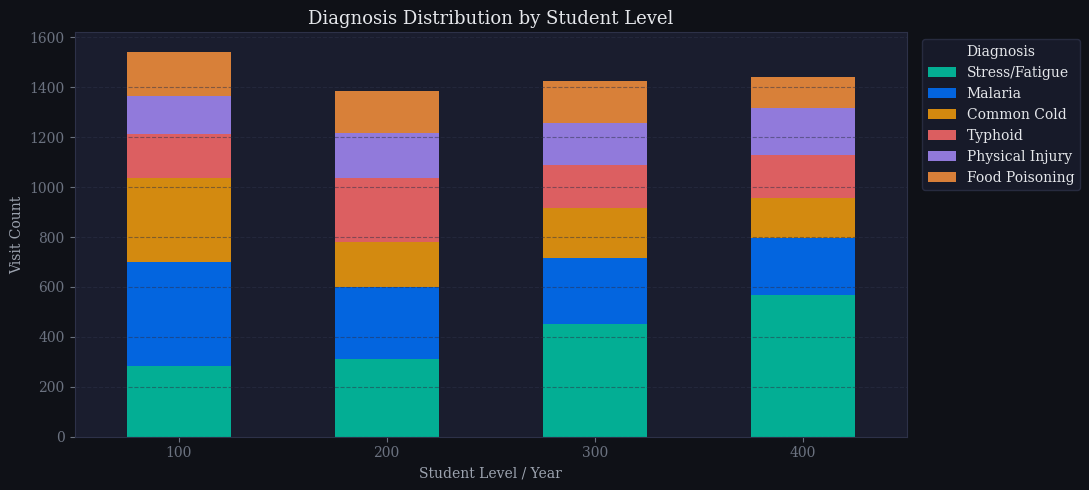

In [15]:
# === 4d. Student Level x Diagnosis ====
level_diag =  pd.crosstab(df['level'],df['diagnosis'])[top_diagnoses]
level_diag.plot(kind='bar', stacked =True, figsize=(11,5),color=PALETTE[:len(top_diagnoses)],alpha=0.85, edgecolor='none')
plt.title('Diagnosis Distribution by Student Level', fontsize=13)
plt.xlabel('Student Level / Year')
plt.ylabel('Visit Count')
plt.xticks(rotation=0)
plt.legend(title='Diagnosis', facecolor='#1a1d2e', edgecolor='#2d3148', bbox_to_anchor=(1.01,1), loc='upper left')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

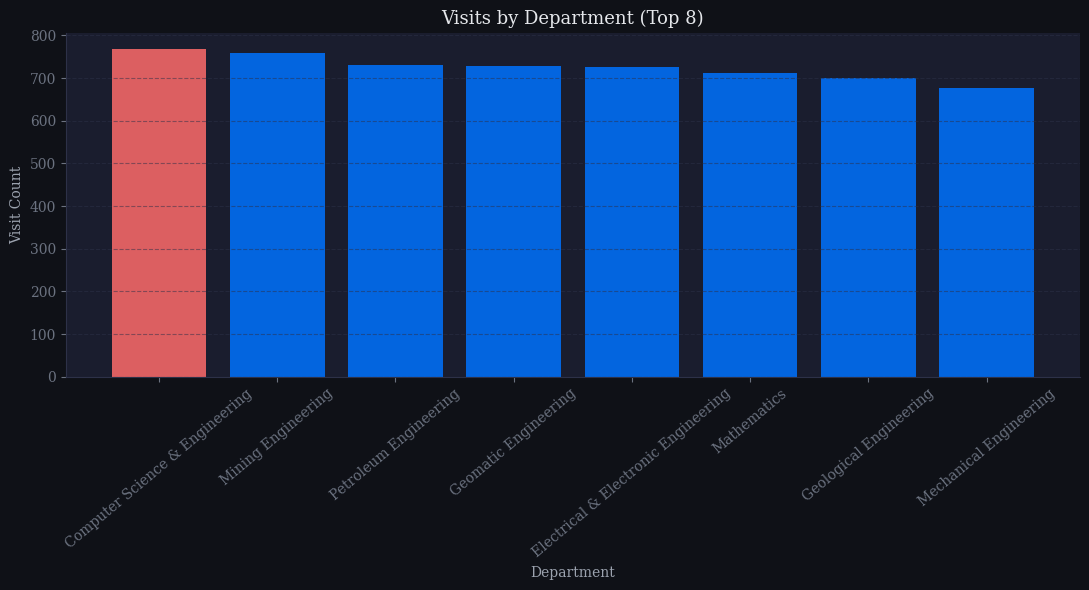

In [16]:
# === 4e. Department visit frequency ===
dept_counts = df['department'].value_counts().head(12)

fig, ax = plt.subplots(figsize=(11, 6))
colors = [RED if v == dept_counts.max() else BLUE for v in dept_counts.values]
ax.bar(dept_counts.index, dept_counts.values, color=colors, alpha=0.85, edgecolor='none')
ax.set_title('Visits by Department (Top 8)', fontsize=13)
ax.set_xlabel('Department')
ax.set_ylabel('Visit Count')
ax.tick_params(axis='x', rotation=40)
ax.grid(axis='y')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

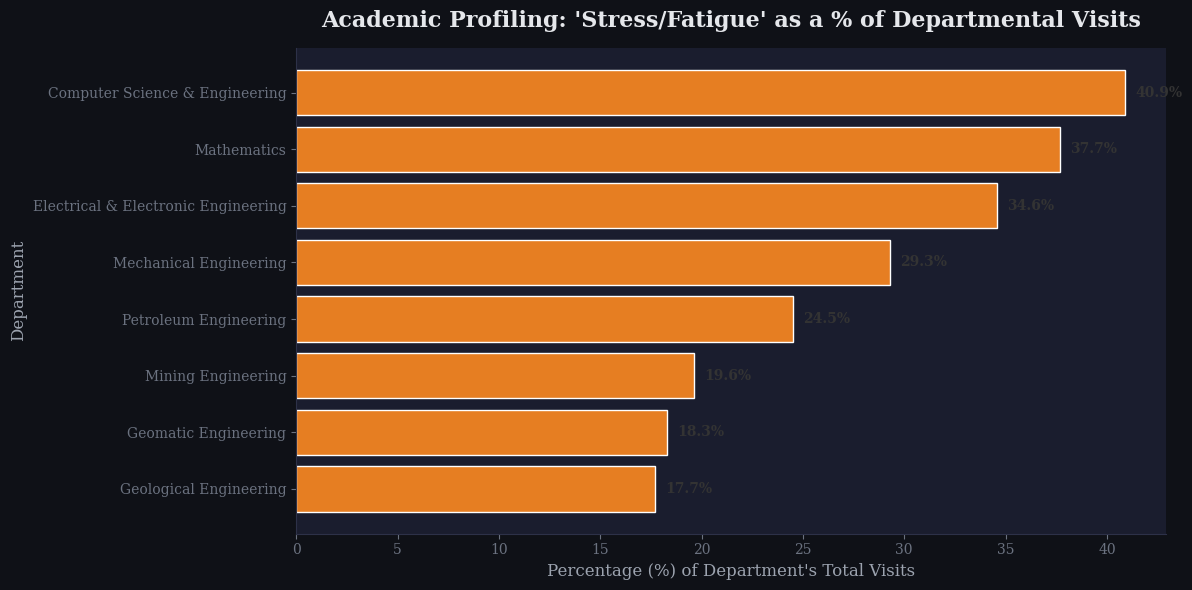

In [17]:
# === 4f. Department vs. Stress/Fatigue (Proving Academic Load)===

# Here, normalize='index' converts the raw counts into percentages across the row.
# This answers: "Out of ALL visits from CS students, what % were for Stress?"
dept_diagnosis_pct = pd.crosstab(df['department'], df['diagnosis'], normalize='index') * 100

# Isolate just the 'Stress/Fatigue' column and sort it
stress_data = dept_diagnosis_pct['Stress/Fatigue'].sort_values(ascending=True)

fig, ax2 = plt.subplots(figsize=(12, 6))
# Using a horizontal bar chart (barh) because department names are long
bars = ax2.barh(stress_data.index, stress_data.values, color='#e67e22', edgecolor='white')

ax2.set_title("Academic Profiling: 'Stress/Fatigue' as a % of Departmental Visits", fontsize=16, fontweight='bold', pad=15)
ax2.set_xlabel("Percentage (%) of Department's Total Visits", fontsize=12)
ax2.set_ylabel("Department", fontsize=12)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Engineering Polish: Add the exact percentage text to the end of each bar
for bar in bars:
    width = bar.get_width()
    ax2.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{width:.1f}%',
             va='center', ha='left', fontsize=10, color='#333333', fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Time Analysis

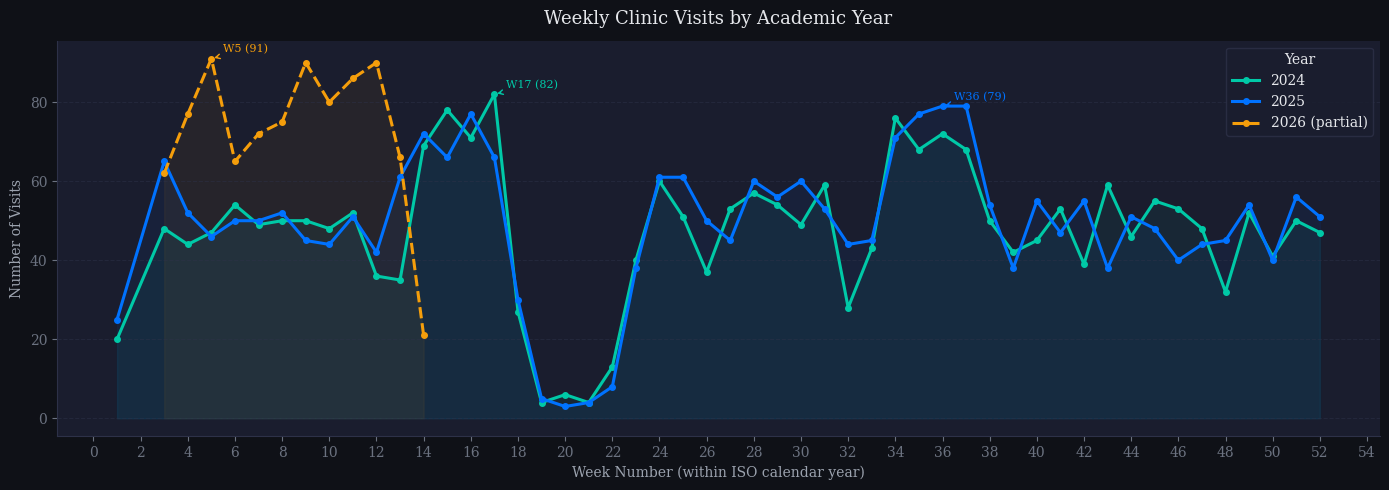

In [18]:
# === 5a. Weekly visit trend — year-aware ===
# Adds a 'year' column temporarily to separate the three cohorts.

df['year'] = df['visit_date'].dt.year

weekly_by_year = (
    df.groupby(['year', 'week_number'])
    .size()
    .reset_index(name='visit_count')
)

fig, ax = plt.subplots(figsize=(14, 5))

year_colors = {2024: TEAL, 2025: BLUE, 2026: AMBER}
year_styles = {2024: '-', 2025: '-', 2026: '--'}  # 2026 dashed = partial year

for year, group in weekly_by_year.groupby('year'):
    label = f'{year}' + (' (partial)' if year == 2026 else '')
    ax.fill_between(
        group['week_number'], group['visit_count'],
        alpha=0.06, color=year_colors[year]
    )
    ax.plot(
        group['week_number'], group['visit_count'],
        color=year_colors[year], linewidth=2.2,
        linestyle=year_styles[year],
        marker='o', markersize=4, label=label
    )
    # Annotate peak for each year
    peak = group.loc[group['visit_count'].idxmax()]
    ax.annotate(
        f"W{int(peak['week_number'])} ({int(peak['visit_count'])})",
        xy=(peak['week_number'], peak['visit_count']),
        xytext=(peak['week_number'] + 0.5, peak['visit_count'] + 1.5),
        color=year_colors[year], fontsize=8,
        arrowprops=dict(arrowstyle='->', color=year_colors[year], lw=1)
    )

ax.set_title('Weekly Clinic Visits by Academic Year', fontsize=13, pad=12)
ax.set_xlabel('Week Number (within ISO calendar year)')
ax.set_ylabel('Number of Visits')
ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
ax.legend(title='Year', facecolor='#1a1d2e', edgecolor='#2d3148')
ax.grid(axis='y')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# Drop the temporary year column
df = df.drop(columns=['year'])

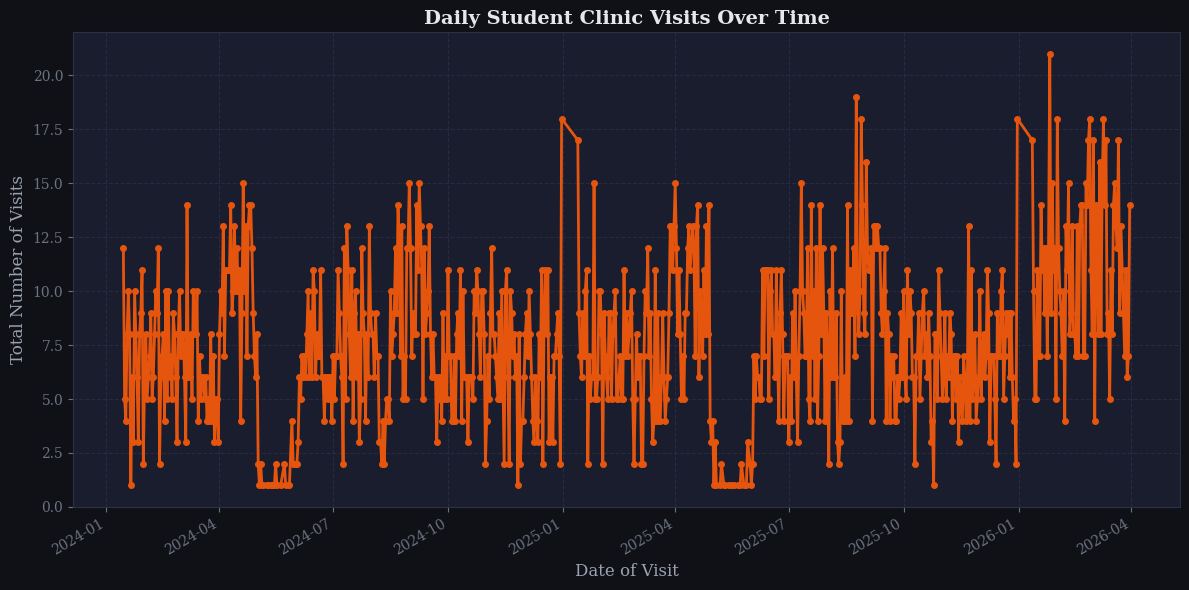

In [19]:
# === 5b. Student clinic visit over time ===
# 1. Convert the 'date_of_visit' column from strings to actual Pandas datetime objects
df['visit_date'] = pd.to_datetime(df['visit_date'])

# 2. Group the data by date to count how many visits happened each day
daily_visits = df.groupby('visit_date').size()

# 3. Plot the time-series line chart
plt.figure(figsize=(12, 6))
daily_visits.plot(kind='line', color='#E6550D', linewidth=2, marker='o', markersize=4)

# 4. Add formatting and labels
plt.title('Daily Student Clinic Visits Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date of Visit', fontsize=12)
plt.ylabel('Total Number of Visits', fontsize=12)

# Add a subtle grid to make reading the peaks and valleys easier
plt.grid(True, linestyle='--', alpha=0.7) 
plt.tight_layout()

# Render the plot
plt.show()

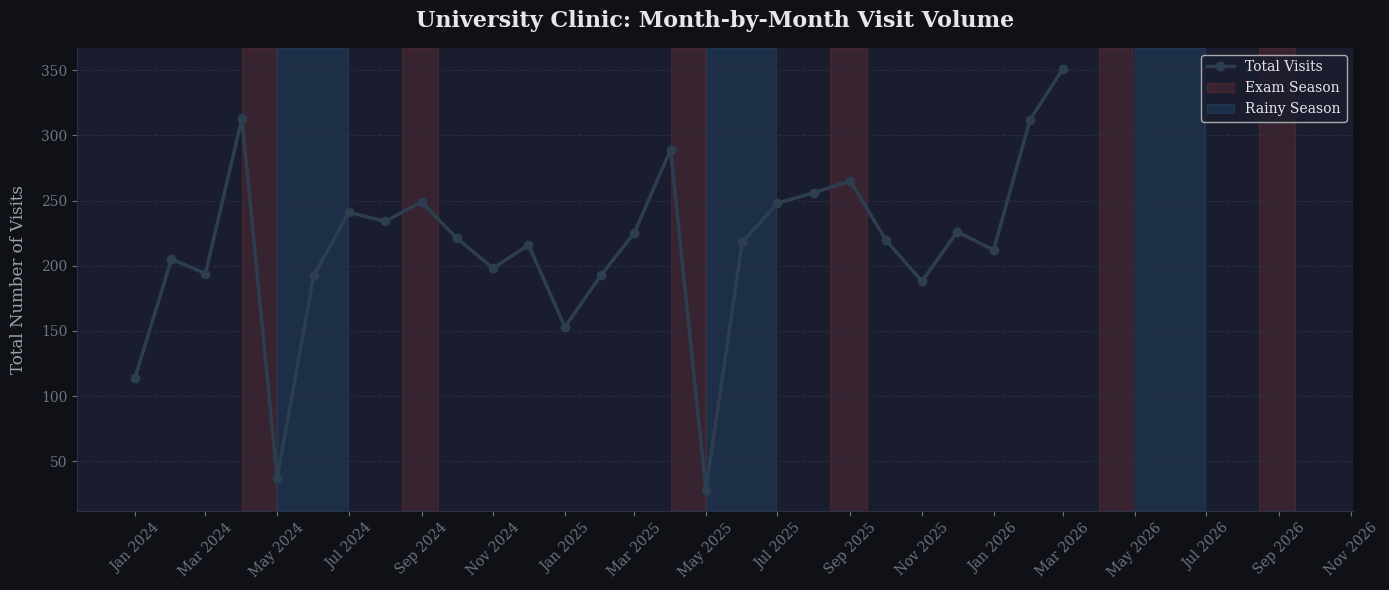

In [20]:
# === 5c. Monthly visit volume ===
# 1. Create a 'Year-Month' column for grouping
# We convert it to a timestamp (the 1st of each month) so matplotlib handles the x-axis cleanly
df['year_month'] = df['visit_date'].dt.to_period('M').dt.to_timestamp()

# 2. Group by Month to get the total volume of clinic visits
monthly_visits = df.groupby('year_month').size()

# 3. Initialize the plot with a professional aspect ratio
fig, ax = plt.subplots(figsize=(14, 6))

# Plot the main trend line
ax.plot(monthly_visits.index, monthly_visits.values, 
        marker='o', linestyle='-', linewidth=2.5, color='#2c3e50', label='Total Visits')

# 4. Add "Engineering Intelligence" - Highlight Exam and Rainy Seasons
# We iterate through the unique years in our dataset to shade them automatically
years = df['visit_date'].dt.year.unique()

for year in years:
    # Highlight April & August (Exam Seasons) - Light Red
    ax.axvspan(pd.Timestamp(f'{year}-04-01'), pd.Timestamp(f'{year}-04-30'), 
               color='#e74c3c', alpha=0.15, label='Exam Season' if year == years[0] else "")
    ax.axvspan(pd.Timestamp(f'{year}-08-15'), pd.Timestamp(f'{year}-09-15'), 
               color='#e74c3c', alpha=0.15)

    # Highlight Rainy Season (May - June) - Light Blue
    ax.axvspan(pd.Timestamp(f'{year}-05-01'), pd.Timestamp(f'{year}-06-30'), 
               color='#3498db', alpha=0.15, label='Rainy Season' if year == years[0] else "")

# 5. Formatting the chart for an Academic Report
ax.set_title("University Clinic: Month-by-Month Visit Volume", fontsize=16, fontweight='bold', pad=15)
ax.set_ylabel("Total Number of Visits", fontsize=12, labelpad=10)

# Clean up the x-axis dates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2)) # Show every 2 months
plt.xticks(rotation=45)

# Add grid, legend, and remove heavy borders for a clean look
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

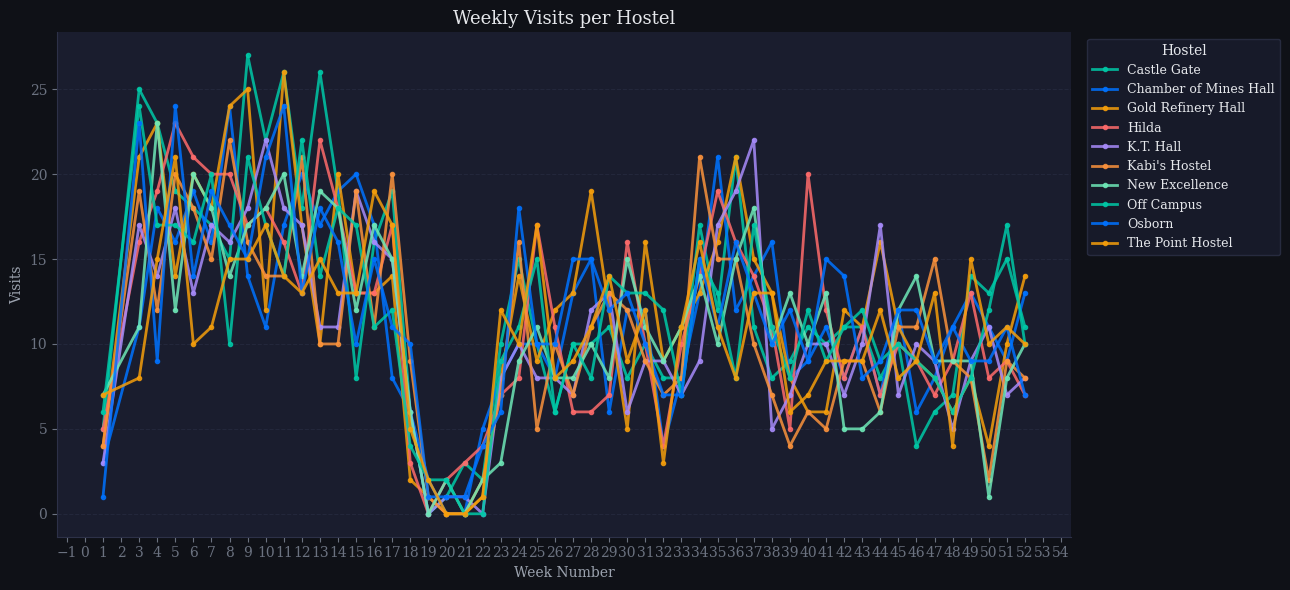

In [21]:
# === 5d. Weekly trend per hostel ===
hostel_weekly = df.groupby(['week_number', 'hostel']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(13, 6))
for i, hostel in enumerate(hostel_weekly.columns):
    ax.plot(hostel_weekly.index, hostel_weekly[hostel],
            label=hostel, color=PALETTE[i % len(PALETTE)],
            linewidth=2, marker='o', markersize=3, alpha=0.85)

ax.set_title('Weekly Visits per Hostel', fontsize=13)
ax.set_xlabel('Week Number')
ax.set_ylabel('Visits')
ax.legend(title='Hostel', facecolor='#1a1d2e', edgecolor='#2d3148',
          bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.grid(axis='y')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

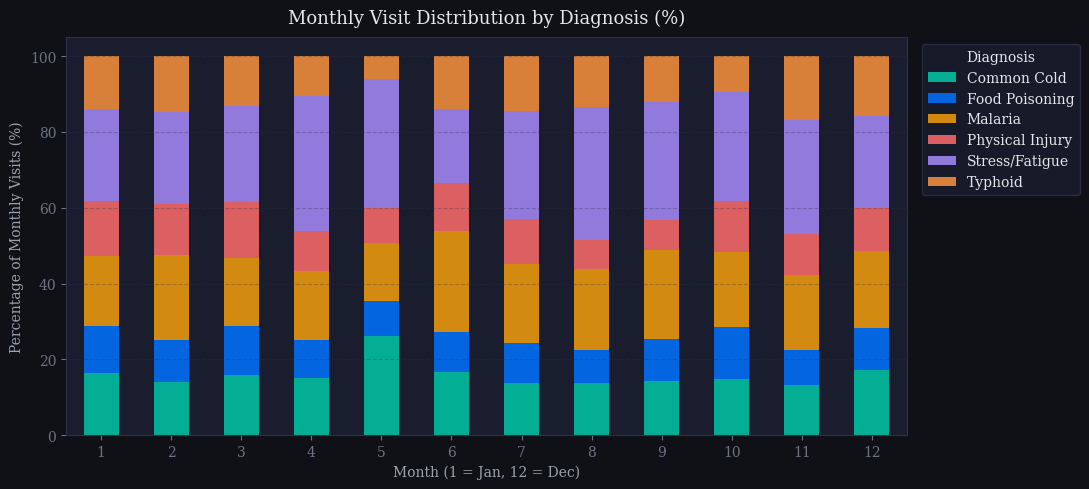

In [22]:
# === 5e. Monthly trend with diagnosis breakdown ===

# 1. Filter the dataset for your top diagnoses as you did before
filtered_df = df[df['diagnosis'].isin(top_diagnoses)]

# 2. THE FIX: Create a cross-tabulation and normalize across the rows (index)
# Multiplying by 100 converts the decimals (0.45) into readable percentages (45%)
monthly_diag_pct = pd.crosstab(filtered_df['month'], filtered_df['diagnosis'], normalize='index') * 100

# 3. Plot the normalized DataFrame
monthly_diag_pct.plot(kind='bar', stacked=True, figsize=(11, 5),
                      color=PALETTE[:len(monthly_diag_pct.columns)],
                      alpha=0.85, edgecolor='none')

# 4. Updated Labels for Engineering Accuracy
plt.title('Monthly Visit Distribution by Diagnosis (%)', fontsize=13, pad=10)
plt.xlabel('Month (1 = Jan, 12 = Dec)')
plt.ylabel('Percentage of Monthly Visits (%)') # Changed from 'Visit Count'
plt.xticks(rotation=0)

# Move legend safely out of the way
plt.legend(title='Diagnosis', facecolor='#1a1d2e', edgecolor='#2d3148',
           bbox_to_anchor=(1.01, 1), loc='upper left')

# Softened the grid for a cleaner aesthetic
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

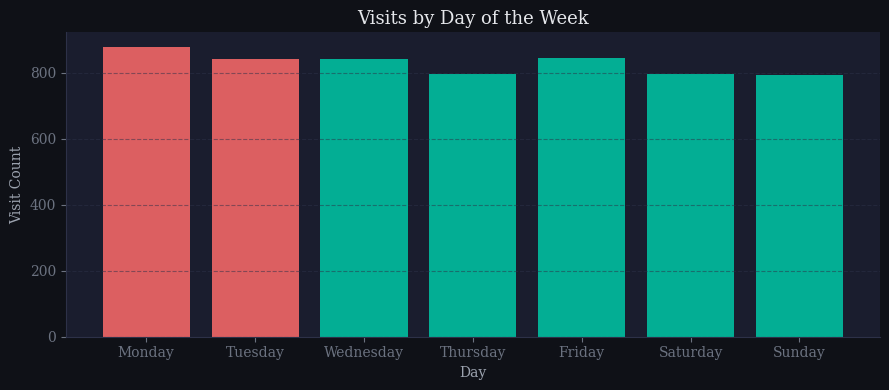

In [23]:
# === 5f. Day-of-week pattern ===
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_counts = df['day_of_week'].value_counts().reindex(day_order).fillna(0)

fig, ax = plt.subplots(figsize=(9, 4))
bar_colors = [RED if d in ['Monday', 'Tuesday'] else TEAL for d in day_order]
ax.bar(day_counts.index, day_counts.values, color=bar_colors, alpha=0.85, edgecolor='none')
ax.set_title('Visits by Day of the Week', fontsize=13)
ax.set_xlabel('Day')
ax.set_ylabel('Visit Count')
ax.grid(axis='y')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

## 6. Severity Analysis¶
Severity is the primary regression target. These cells explore its distribution and relationships before modelling.

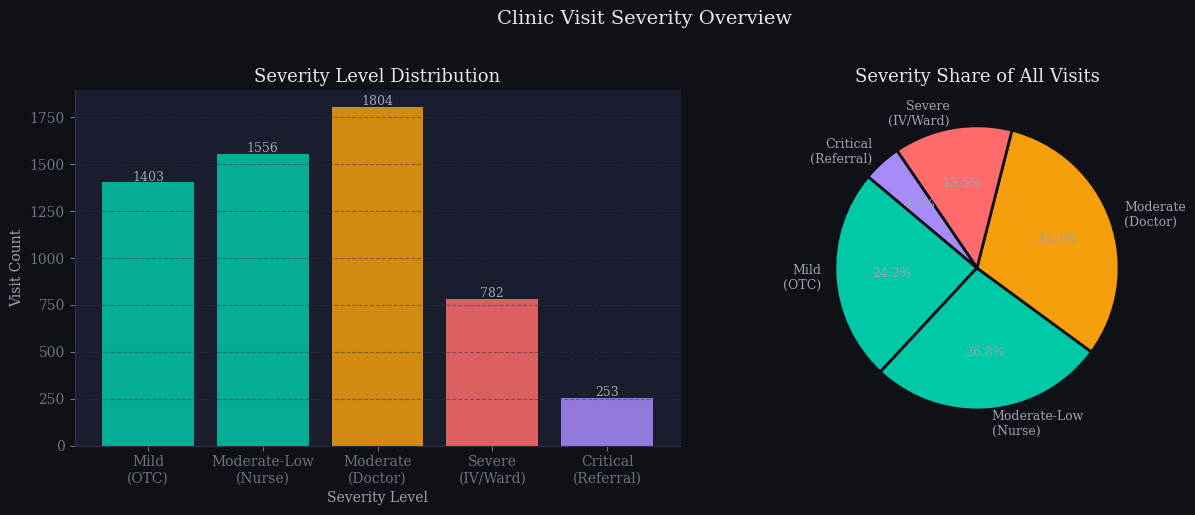

count    5798.00
mean        2.47
std         1.12
min         1.00
25%         2.00
50%         2.00
75%         3.00
max         5.00
Name: severity, dtype: float64


In [24]:
# === 6a. Severity Distribution ===
severity_counts = df['severity'].value_counts().sort_index()
severity_labels = {
    1: 'Mild\n(OTC)',
    2: 'Moderate-Low\n(Nurse)',
    3: 'Moderate\n(Doctor)',
    4: 'Severe\n(IV/Ward)',
    5: 'Critical\n(Referral)'
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
bar_colors = [TEAL, TEAL, AMBER, RED, PURPLE]
bars = axes[0].bar(
    [severity_labels[i] for i in severity_counts.index],
    severity_counts.values,
    color=bar_colors[:len(severity_counts)],
    alpha=0.85, edgecolor='none'
)
for bar, val in zip(bars, severity_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        str(val), ha='center', fontsize=9, color='#9ca3af'
    )
axes[0].set_title('Severity Level Distribution', fontsize=13)
axes[0].set_xlabel('Severity Level')
axes[0].set_ylabel('Visit Count')
axes[0].grid(axis='y')
axes[0].spines[['top', 'right']].set_visible(False)

# Pie chart
axes[1].pie(
    severity_counts.values,
    labels=[severity_labels[i] for i in severity_counts.index],
    colors=bar_colors[:len(severity_counts)],
    autopct='%1.1f%%', startangle=140,
    textprops={'color': '#9ca3af', 'fontsize': 9},
    wedgeprops={'edgecolor': '#0f1117', 'linewidth': 2}
)
axes[1].set_title('Severity Share of All Visits', fontsize=13)

plt.suptitle('Clinic Visit Severity Overview', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(df['severity'].describe().round(2))

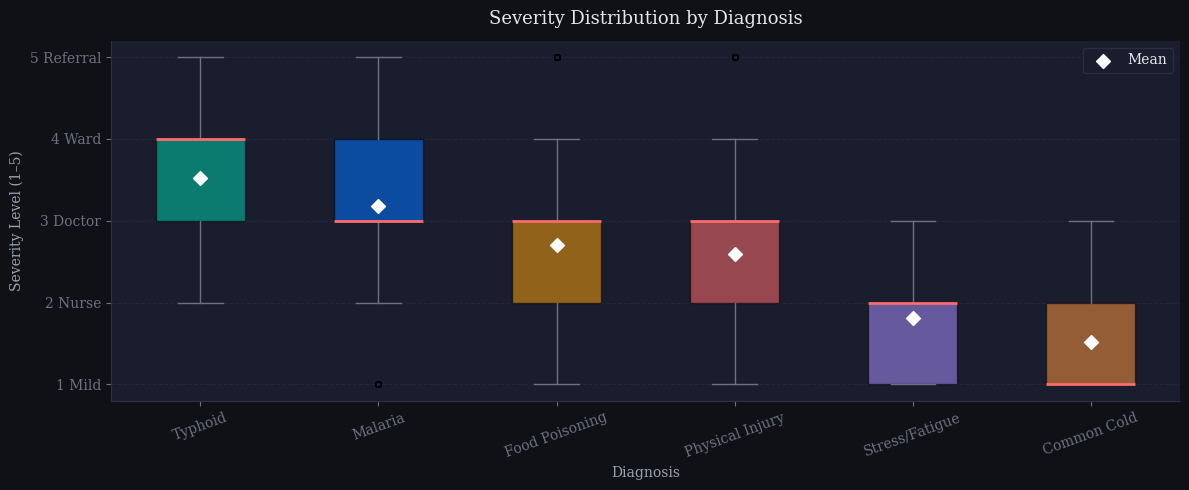

Mean severity per diagnosis:
diagnosis
Typhoid            3.52
Malaria            3.18
Food Poisoning     2.71
Physical Injury    2.60
Stress/Fatigue     1.81
Common Cold        1.52


In [25]:
# === 6b. Average Severity by Diagnosis (Boxplot + Mean markers) ===
# This is the most important severity chart — shows what the regression model
# will need to learn: Typhoid and Malaria sit far above Stress/Fatigue and Cold.

diag_order = (
    df.groupby('diagnosis')['severity']
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)

fig, ax = plt.subplots(figsize=(12, 5))

groups = [df[df['diagnosis'] == d]['severity'].values for d in diag_order]

bp = ax.boxplot(
    groups,
    labels=diag_order,
    patch_artist=True,
    medianprops=dict(color=RED, linewidth=2),
    whiskerprops=dict(color='#6b7280'),
    capprops=dict(color='#6b7280'),
    flierprops=dict(marker='o', alpha=0.3, markersize=4, color=AMBER)
)
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.55)

# Overlay mean markers
means = [df[df['diagnosis'] == d]['severity'].mean() for d in diag_order]
ax.scatter(range(1, len(diag_order) + 1), means,
           color='white', zorder=5, s=50, marker='D', label='Mean')

ax.set_title('Severity Distribution by Diagnosis', fontsize=13, pad=12)
ax.set_xlabel('Diagnosis')
ax.set_ylabel('Severity Level (1–5)')
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(['1 Mild', '2 Nurse', '3 Doctor', '4 Ward', '5 Referral'])
ax.legend(facecolor='#1a1d2e', edgecolor='#2d3148')
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# Print mean table
print('Mean severity per diagnosis:')
print(df.groupby('diagnosis')['severity'].mean().round(2).sort_values(ascending=False).to_string())

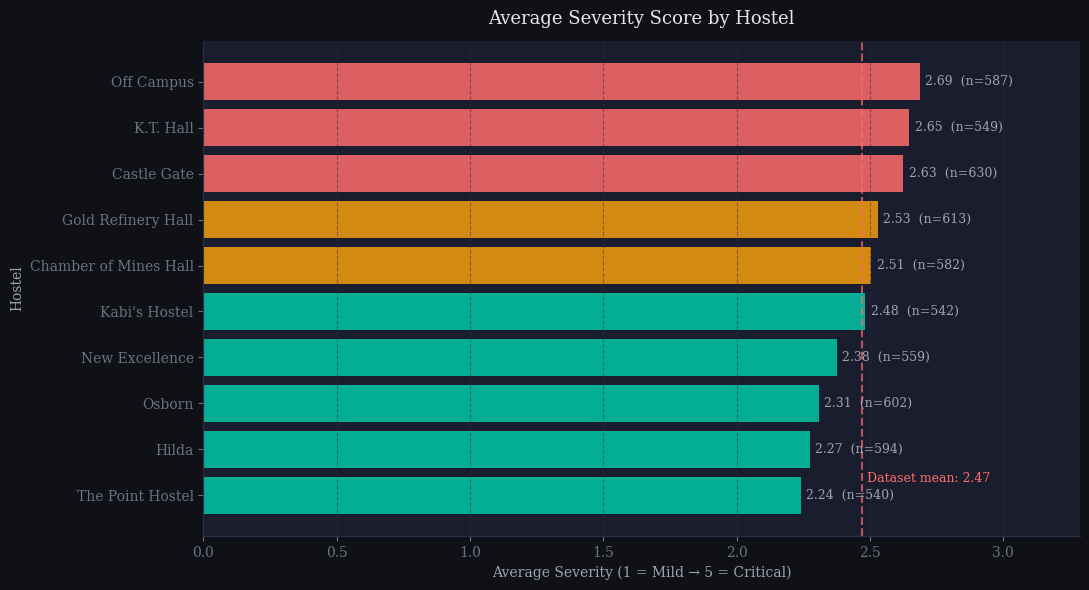

In [26]:
# === 6c. Average Severity by Hostel ===
# Reveals which hostels produce not just more visits but worse cases.
# K.T. Hall high in Malaria should also score higher in avg severity.

hostel_severity = (
    df.groupby('hostel')['severity']
    .agg(['mean', 'count'])
    .sort_values('mean', ascending=True)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 6))

bar_colors = [
    RED if v >= hostel_severity['mean'].quantile(0.75)
    else AMBER if v >= hostel_severity['mean'].quantile(0.5)
    else TEAL
    for v in hostel_severity['mean']
]

bars = ax.barh(
    hostel_severity['hostel'],
    hostel_severity['mean'],
    color=bar_colors, alpha=0.85, edgecolor='none'
)

# Add mean value labels
for bar, val, count in zip(bars, hostel_severity['mean'], hostel_severity['count']):
    ax.text(
        bar.get_width() + 0.02,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.2f}  (n={count})',
        va='center', fontsize=9, color='#9ca3af'
    )

# Reference line at dataset mean
overall_mean = df['severity'].mean()
ax.axvline(overall_mean, color=RED, linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(overall_mean + 0.02, 0.3, f'Dataset mean: {overall_mean:.2f}',
        color=RED, fontsize=9)

ax.set_title('Average Severity Score by Hostel', fontsize=13, pad=12)
ax.set_xlabel('Average Severity (1 = Mild → 5 = Critical)')
ax.set_ylabel('Hostel')
ax.set_xlim(0, hostel_severity['mean'].max() + 0.6)
ax.grid(axis='x')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

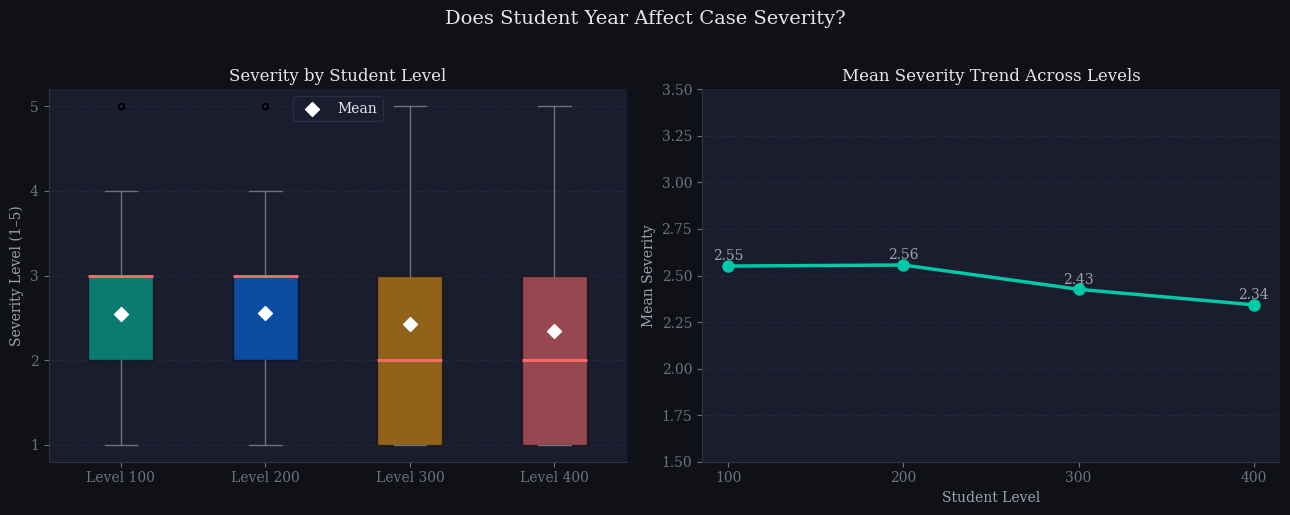

In [27]:
# === 6d. Severity by Student Level ===
# Tests the hypothesis: Level 100 students present later and have worse cases.
# Level 400 students are experienced and catch things early — lower severity.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot
level_groups = [df[df['level'] == lvl]['severity'].values for lvl in [100, 200, 300, 400]]
bp = axes[0].boxplot(
    level_groups,
    labels=['Level 100', 'Level 200', 'Level 300', 'Level 400'],
    patch_artist=True,
    medianprops=dict(color=RED, linewidth=2),
    whiskerprops=dict(color='#6b7280'),
    capprops=dict(color='#6b7280'),
    flierprops=dict(marker='o', alpha=0.3, markersize=4, color=AMBER)
)
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.55)

level_means = [df[df['level'] == lvl]['severity'].mean() for lvl in [100, 200, 300, 400]]
axes[0].scatter([1, 2, 3, 4], level_means, color='white', zorder=5, s=50, marker='D', label='Mean')
axes[0].set_title('Severity by Student Level', fontsize=12)
axes[0].set_ylabel('Severity Level (1–5)')
axes[0].set_yticks([1, 2, 3, 4, 5])
axes[0].legend(facecolor='#1a1d2e', edgecolor='#2d3148')
axes[0].grid(axis='y')
axes[0].spines[['top', 'right']].set_visible(False)

# Mean severity line chart across levels
axes[1].plot(
    ['100', '200', '300', '400'], level_means,
    color=TEAL, linewidth=2.5, marker='o', markersize=8
)
for i, (x, y) in enumerate(zip(['100', '200', '300', '400'], level_means)):
    axes[1].text(i, y + 0.03, f'{y:.2f}', ha='center', fontsize=10, color='#9ca3af')

axes[1].set_title('Mean Severity Trend Across Levels', fontsize=12)
axes[1].set_xlabel('Student Level')
axes[1].set_ylabel('Mean Severity')
axes[1].set_ylim(1.5, 3.5)
axes[1].grid(axis='y')
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Does Student Year Affect Case Severity?', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Key Insights Summary

In [ ]:
# === Key Insights Summary (updated — includes severity) ===
total_visits     = len(df)
top_diag         = df['diagnosis'].value_counts().idxmax()
top_diag_pct     = df['diagnosis'].value_counts().max() / total_visits * 100
top_hostel       = df['hostel'].value_counts().idxmax()
peak_wk          = weekly_by_year.loc[weekly_by_year['visit_count'].idxmax()]
top_gender       = df['gender'].value_counts().idxmax()
top_level        = df['level'].value_counts().idxmax()
avg_severity     = df['severity'].mean()
top_severe_diag  = df.groupby('diagnosis')['severity'].mean().idxmax()
top_severe_hostel= df.groupby('hostel')['severity'].mean().idxmax()
pct_critical     = (df['severity'] >= 4).sum() / total_visits * 100

print('=' * 57)
print('            EDA SUMMARY — KEY FINDINGS')
print('=' * 57)
print(f'  Total Records Analysed  : {total_visits:,}')
print(f'  Date Range              : {df["visit_date"].min().date()} → {df["visit_date"].max().date()}')
print()
print('  ── Visit Patterns ──────────────────────────────')
print(f'  Top Diagnosis           : {top_diag} ({top_diag_pct:.1f}%)')
print(f'  Highest Visit Hostel    : {top_hostel}')
print(f'  Peak Visit Week         : Week {int(peak_wk["week_number"])} ({int(peak_wk["visit_count"])} visits)')
print(f'  Most Visits by Gender   : {top_gender}')
print(f'  Most Visits by Level    : Year {top_level}')
print()
print('  ── Severity (Regression Target) ────────────────')
print(f'  Average Severity        : {avg_severity:.2f} / 5.00')
print(f'  Highest Severity Diag   : {top_severe_diag}')
print(f'  Highest Severity Hostel : {top_severe_hostel}')
print(f'  Critical Cases (4–5)    : {pct_critical:.1f}% of all visits')
print('=' * 57)
print()
print('  NEXT: ML Modelling')
print('  → Classification : predict diagnosis from visit features')
print('  → Regression     : predict severity score')
print('  → Clustering     : group hostels by illness profile')

            EDA SUMMARY — KEY FINDINGS
  Total Records Analysed  : 5,798
  Date Range              : 2024-01-15 → 2026-03-31

  ── Visit Patterns ──────────────────────────────
  Top Diagnosis           : Stress/Fatigue (27.9%)
  Highest Visit Hostel    : Castle Gate
  Peak Visit Week         : Week 5 (91 visits)
  Most Visits by Gender   : Male
  Most Visits by Level    : Year 100

  ── Severity (Regression Target) ────────────────
  Average Severity        : 2.47 / 5.00
  Highest Severity Diag   : Typhoid
  Highest Severity Hostel : Off Campus
  Critical Cases (4–5)    : 17.9% of all visits

  NEXT: ML Modelling
  → Classification : predict diagnosis from visit features
  → Regression     : predict severity score
  → Clustering     : group hostels by illness profile


: 